**Solubilidad del Alcafor en sCO2**
* E.O.S = PR
* Reglas de Mezclado: Van der Waals
* Parametros de interaccion binaria lij y kij -> Pero tomaremos ya los encontrados por el articulo, dado que nos faltan propiedades intensivas para poder hacer el ajuste nosotras mismas. 
* OBJ: Identificar cuando el sistema esta en equilibrio o no. 
* Datos experimentales obtenidos de:
    * Carvalho, R. N., Corazza, M. L., Cardozo-Filho, L., & Meireles, M. A. A. (2006).
          Phase Equilibrium for (Camphor + CO2), (Camphor + Propane), and (Camphor + CO2 +
          Propane). Journal of Chemical & Engineering Data, 51(3), 997–1000.
          https://nebulosa.icesi.edu.co:2144/10.1021/je0505063
    * Cálculo del flash Isotermico (T, P) — documentación de PyTher - 0. (n.d.). Retrieved from https://pyther.readthedocs.io/es/latest/flash.html

**Algoritmo**
1. Definir funcion de Peng Robinson para nuestra mezcla de interes, con parametros de interaccion binaria del articulo. -> Funcion o incluso clase  
2. Determinar los puntos de equilibrio
    * Iterar sobre Temperaturas (rango nuestro) y Presiones (rango nuestro). Especificar #moles en el sistema (sistema global composicion (nos vamos a basar en algun articulo))
    * Calcular el coeficiente de distribución Ki a partir de la relación de Wilson -> Adivinanza inicial -> Funcion
    * Calcular el valor de Beta mínimo 
    * Calcular el valor de Beta máximo
    * Calcular el promedio de beta, usando Beta minimo y Beta máximo
    * Si el promedio da por debajo de 0 o por encima de 1, a esas condiciones no se encuentra en equilibrio.
    * Resolver la ecuación de Rachford-Rice, para calcular Beta con una tolerancia de 1e-6
    * Calcular las fracciones molares del líquido xi y del vapor yi
    * Calcular los coeficientes de fugacidad para las fracciones molares del líquido xi y del vapor yi (funcion de sofi)
    * Calcular el coeficiente de distribución Ki a partir de los coeficientes de fugacidad del componente i en la mezcla de la fase vapor y líquid
    * Verificar la convergencia del sistema con una tolerancia de 1e-6 para deltaKi

In [61]:
#Imports
import numpy as np
from scipy.optimize import root
from scipy.optimize import minimize
import plotly.graph_objects as go
import chemicals
import matplotlib.pyplot as plt
from typing import Literal 

R = 8.3145e-6 #MJ/molK
# Constantes puras (Alcanfor = 1, CO2 = 2)
sus = ["Alcanfor", "Dioxido de Carbono"]
CAS = np.array([chemicals.search_chemical('camphor').CASs, chemicals.search_chemical('carbon dioxide').CASs])
Tc = np.array([chemicals.Tc(CAS[0]), chemicals.Tc(CAS[1])]) # K
Pc = np.array([chemicals.Pc(CAS[0]), chemicals.Pc(CAS[1])])/(10**6)  # MPa
omega = np.array([chemicals.omega(CAS[0]), chemicals.omega(CAS[1])])
k12, l12 = 5.4695e-2 , -0.6598e-2 #del articulo :)

def calc_eos_cst_pure(T):
    # PR
    b1 = 0.07780*(R*Tc[0]/Pc[0])
    a1 = 0.45724*((R*Tc[0])**2/Pc[0])*(1+(0.37464+1.54226*omega[0]-0.2699*omega[0]**2)*(1-(T/Tc[0])**0.5))**2
    b2 = 0.07780*(R*Tc[1]/Pc[1])
    a2 = 0.45724*((R*Tc[1])**2/Pc[1])*(1+(0.37464+1.54226*omega[1]-0.2699*omega[1]**2)*(1-(T/Tc[1])**0.5))**2
    return a1, b1, a2, b2

def calc_eos_cst_mix(x1, x2, k12, l12, amatriz, bs):
    bmix = bs[0]*x1**2 + 2*x1*x2*(((bs[0]+bs[1])/2)*(1-l12)) + bs[1]*x2**2
    amix = amatriz[0][0]*x1**2 + amatriz[1][0]*x2**2 + 2*amatriz[0][1]*x1*x2
    return amix, bmix

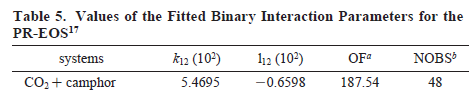

In [2]:
def PR_mix(T, P, amix, bmix, phase : Literal['liquid', 'vapor'] = 'liquid'):
    #z1 es la composicion de alcanfor en la fase que esta representando la ecuacion de Peng Robinson.
    #OBJ: Calcular el volumen de la fase
    #P = MPa
    opciones_validas = ['liquid', 'vapor']
    if phase not in opciones_validas:
        raise ValueError(
            f"phase '{phase}' no es válido. "
            f"Debe ser uno de: {opciones_validas}"
        )
    
    A = (amix * P) / ((R * T) ** 2)
    B = (bmix* P) / (R * T)
    c3 = 1.0
    c2 = -(1.0 - B)
    c1 = A - 2.0 * B - B**2
    c0 = -(A * B - B**2 - B**3)

    raices = np.roots([c3, c2, c1, c0])

    raices_reales = raices[np.isreal(raices)].real

    if len(raices_reales) == 0:
        raise RuntimeError(
            "No se encontraron raíces reales para el factor de compresibilidad Z."
        )

    if phase == "liquid":
        Z = min(raices_reales)
    else:  
        Z = max(raices_reales)

    v = (Z * R * T) / P


    return v


In [ ]:
#needed functions
def wilsonKi(P, Pci, wi, Tci, T):
    return float(np.exp(np.log(Pci/P) + 5.373*(1+wi)*(1-(Tci/T))))

def betaMax(zi, Ki):
    return float((zi - 1)/(1-Ki))

def betaMin(zi, Ki):
    #si hay un error inexplicable, esta puede ser la fuente
    return float((Ki*zi - 1)/(Ki - 1))

def calc_fugacity_coeff(P, T, mole_fractions, a_matrix, b_vector, a_mix, b_mix, phase_type='vapor'):
    y = np.array(mole_fractions)
    b_vector = np.array(b_vector)
    a_matrix = np.array(a_matrix)
    
    A = a_mix * P / (R**2 * T**2)
    B = b_mix * P / (R * T)

    coeff = [
        1.0,
        -(1.0 - B),
        A - 3.0 * B**2 - 2.0 * B,
        -(A * B - B**2 - B**3)
    ]

    roots = np.roots(coeff)
    roots_real = roots[np.isclose(roots.imag, 0.0, atol=1e-9)].real
    roots_real = np.sort(roots_real)

    if len(roots_real) == 0:
        raise ValueError(f"No se encontraron raíces reales para Z a T={T} K y P={P} Pa.")
    
    roots_val = [
        np.real(r) for r in roots_real
        if np.isreal(r) and np.real(r) > B
    ]#redundante

    if phase_type.lower() == 'liquid':
        Z = np.min(roots_val)   
    else:
        Z = np.max(roots_val)

    if Z <= B:
        raise ValueError(f"Raíz no física detectada (Z={Z} <= B={B}).")

    sqrt2 = np.sqrt(2.0)
    arg_log = (Z + (1.0 + sqrt2) * B) / (Z + (1.0 - sqrt2) * B)

    if arg_log <= 0:
        raise ValueError("Argumento logarítmico para el término de atracción es inválido.")

    suma_aj = np.dot(a_matrix, y)

    term1 = (b_vector / b_mix) * (Z - 1.0)
    term2 = -np.log(Z - B)
    term3 = -A / (2.0 * sqrt2 * B)
    term4 = (2.0 * suma_aj / a_mix) - (b_vector / b_mix)
    term5 = np.log(arg_log)

    ln_phi = term1 + term2 + term3 * term4 * term5
    phi = np.exp(ln_phi)

    return phi

def errorRR(beta, Kis, Zis):
    term1 = Zis[0] * (Kis[0] - 1) / (1 + beta * (Kis[0] - 1)) #y1 - x1
    term2 = Zis[1] * (Kis[1] - 1) / (1 + beta * (Kis[1] - 1)) #y2 - x2
    return (term1 + term2)**2 #al beta correcto, deberia dar cero. Pero da igual si los sumo o los resto.


In [4]:
k12, l12 = 5.4695e-2 , -0.6598e-2 #del articulo :)
homogeneous = {}
heterogeneous = {}

def EVL(T, P, z, Tc, Pc, omega, a_matriz, bs, tol=1e-1, max_iter=200):
    K = [wilsonKi(P, Pc[0], omega[0], Tc[0], T), wilsonKi(P, Pc[1], omega[1], Tc[1], T)]
    Bmax = np.average([betaMax(z[0], K[0]),betaMax(z[1],K[1])])
    Bmin = np.average([betaMin(z[0], K[0]), betaMin(z[1], K[1])])
    
    #tienen el mismo indice, porque en este caso el beta es el mismo para las dos sustancias, entonces da igual. 
    # Pero tienen valores de K diferentes y proporciones diferentes en el sistema. No se, pero por consistencia, los betas se deberian calcular con la misma sustancia. 
    # Me gustaria revisar si dan los mismo. Si no dan lo mismo, en cual confiaria? El que de mejor promedio, no?
    print(f"Sustancia \nBmax:{Bmax}\nBmin:{Bmin}")
    #si dan diferente pero no por tanto entonces no se alli que :). Creo que lo mejor seria el promedio de las cosas, sabes?
    B0 = (Bmax + Bmin) / 2.0
    if B0 < 0 or B0 > 1:
        print("Beta not within range!")
        return None
    else:
        print("Beta within range!")
        error = 100
        for i in range(max_iter):
            # sol = root(errorRR, [0.5], args=(K, z))
            sol = minimize(errorRR, 0.5, args = (K, z), bounds= [(0,1)], tol= 1e-3) #encuentre como satisfactorio los valores negativos (creo), mientras sean mas pequeños
            # print(f"minimize sols: {sol_minimize.success} , x: {sol_minimize.x}")
            if sol.success:
                print("success!")
                beta = float(sol.x[0])
                if 0.0 <= beta <= 1.0:
                    y1 = K[0]*z[0]/(1-beta + beta*K[0])
                    x1 = z[0]/(1-beta + beta*K[0])
                    y2 = K[1]*z[1]/(1-beta + beta*K[1])
                    x2 = z[1]/(1-beta + beta*K[1])
                    #Problem: y1 + y2 != 1 and x1 + x2 != 1. Puedo siempre sacar la otra por despeje, pero en cual confio, sabes?
                    amixV, bmixV = calc_eos_cst_mix(y1, y2, k12, l12, a_matriz, bs)
                    amixL, bmixL = calc_eos_cst_mix(x1, x2, k12, l12, a_matriz, bs)
                    phiL = calc_fugacity_coeff(P, T, [x1, x2], a_matriz, bs, amixL, bmixL, phase_type='liquid')
                    phiV = calc_fugacity_coeff(P, T, [y1,y2], a_matriz, bs, amixV, bmixV, phase_type='vapor') 
                    Ks = phiL/phiV

                    delta_K = np.linalg.norm(Ks - K)
                    if delta_K < tol:
                        print("return not None")
                        return [x1,x2], [y1,y2], beta 
                        
                    K = Ks
                
                else:    
                    return None
        
            else:
                return None
                    

In [71]:
Ts = np.linspace(298.15, (60+273.15), 1000)
Ps = np.linspace(Pc[1], 1300/145, 3)
z1 = 0.0015 #
z2 = 1 - z1
x_camphor = {}
y_camphor = {}
Teq = {}
for P in Ps:
        print(f"P: {P}")
        Teq[P] = []
        x_camphor[P] = []
        y_camphor[P] = []
        for T in Ts:         
            print(f"T: {T}")                       
            a1, b1, a2, b2 = calc_eos_cst_pure(T)
            a12 = np.sqrt(a1 * a2) * (1.0 - k12)
            a_matriz = [[a1, a12],[a12,a2]]
            bs = [b1, b2]
            result = EVL(T, P, [z1, z2], Tc, Pc, omega, a_matriz, bs, tol = 1e-6, max_iter=200)
            if result is not None:
                print('*')
                heterogeneous[P] = T
                x, y, beta = result
                x_camphor[P].append(x[0])
                y_camphor[P].append(y[0])
                Teq[P].append(T)
                
            else:
                homogeneous[P] = T  
                print('O')

print(f"x_camphor = {x_camphor} , \n y_cmaphor = {y_camphor}, \n Teq [P:array[Teqs]] = {Teq}, \n heterogeneous [P:Teq]= {heterogeneous}, \n homogeneous [P:Teq]= {homogeneous}")


plt.figure(figsize=(8, 6))
for P in Ps:   
    if len(Teq[P]) > 0:
        plt.plot(x_camphor[P], Teq[P], 'b-', label=f'x1,{P}')
        plt.plot(y_camphor[P], Teq[P], 'r-', label=f'y1,{P}')
plt.xlabel('Fracción Molar de Alcanfor ($x_1, y_1$)')
plt.ylabel('Temperatura (K)')
plt.title(f'Diagrama de Equilibrio T-x-y MPa')
plt.grid(True)
plt.legend()
plt.show()

P: 7.3773
T: 298.15
Sustancia 
Bmax:-0.505332706220467
Bmin:1.005332706220467
Beta within range!
success!
success!
success!
O
T: 298.185035035035
Sustancia 
Bmax:-0.5053668823164194
Bmin:1.005366882316419
Beta within range!


C:\Users\premz\AppData\Local\Temp/ipykernel_41008/2820903037.py:87: RuntimeWarning: overflow encountered in exp
  phi[i] = np.exp(ln_phi)
C:\Users\premz\AppData\Local\Temp/ipykernel_41008/4006613361.py:67: RuntimeWarning: invalid value encountered in true_divide
  term1 = Zis[0] * (Kis[0] - 1) / (1 + beta * (Kis[0] - 1)) #y1 - x1
C:\Users\premz\AppData\Local\Temp/ipykernel_41008/4006613361.py:68: RuntimeWarning: invalid value encountered in true_divide
  term2 = Zis[1] * (Kis[1] - 1) / (1 + beta * (Kis[1] - 1)) #y2 - x2


success!
success!
success!
O
T: 298.22007007007005
Sustancia 
Bmax:-0.5054014641008713
Bmin:1.0054014641008715
Beta within range!
success!
success!
success!
O
T: 298.2551051051051
Sustancia 
Bmax:-0.5054364588331807
Bmin:1.0054364588331806
Beta within range!
success!
success!
success!
O
T: 298.2901401401401
Sustancia 
Bmax:-0.5054718739469614
Bmin:1.0054718739469612
Beta within range!
success!
success!
success!
O
T: 298.32517517517516
Sustancia 
Bmax:-0.5055077170553436
Bmin:1.0055077170553437
Beta within range!
success!
success!
success!
O
T: 298.3602102102102
Sustancia 
Bmax:-0.5055439959564266
Bmin:1.005543995956427
Beta within range!
success!
success!
success!
O
T: 298.39524524524523
Sustancia 
Bmax:-0.5055807186389302
Bmin:1.0055807186389303
Beta within range!
success!
success!
success!
O
T: 298.4302802802803
Sustancia 
Bmax:-0.5056178932880548
Bmin:1.005617893288055
Beta within range!
success!
success!
success!
O
T: 298.4653153153153
Sustancia 
Bmax:-0.5056555282915599
Bmin:1.005

KeyboardInterrupt: 

**Try 2**

Flash Ideal

In [45]:
def rice(z, K, Bini):
    # Ecuación de Rachford-Rice para el equilibrio líqudo-vapor
    fg = np.sum(z * (K - 1) / (1 - Bini + Bini * K))
    dfg = - np.sum(z * (K - 1) ** 2 / (1 - Bini + Bini * K) ** 2)
    return fg, dfg

def composicion_xy(z, Bini, K):
    # Ecuación de Rachford-Rice para calcular la composición del equilibrio líqudo-vapor
    xi = z/ (1 - Bini + Bini * K)
    yi = (z * K) / (1 - Bini + Bini * K)
    li = (z * (1 - Bini)) / (1 - Bini + Bini * K)
    vi = (z * Bini * K) / (1 - Bini + Bini * K)

    return xi, yi, li, vi

def flash_ideal(T, P, z):
    # Solución del flash (T,P,ni) isotermico para Ki_(T,P)
    K = np.array([wilsonKi(P, Pc[0], omega[0], Tc[0], T), wilsonKi(P, Pc[1], omega[1], Tc[1], T)])
    Bmax = np.min([betaMax(z[0], K[0]),betaMax(z[1],K[1])])
    Bmin = np.max([betaMin(z[0], K[0]), betaMin(z[1], K[1])])
    Bini = (Bmax + Bmin) / 2.0
    Eg = rice(z, K, Bini)
    errorEq = abs(Eg[0])
    # Especificaciones del método Newton precario, mientras se cambia por una librería Scipy
    i, s, ep = 0, 1, 1e-5

    while errorEq > ep:
        Eg = rice(z, K, Bini)
        Bini = Bini - s * Eg[0] / Eg[1]
        errorEq = abs(Eg[0])
        i += 1
        if i >= 50:
            break

    xi, yi, li, vi = composicion_xy(z, Bini, K)
    print ("-"*53, "\n", "-"*18, "Mole fraction", "-"*18, "\n","-"*53)
    print ("\n", "-"*13, "Zi phase composition", "-"*13, "\n")
    print ("{0} = {1} \n{2} = {3} \n".format(sus[0], z[0],sus[1], z[1]))
    print ("Sumatoria zi = {0}".format(np.sum(z)))
    print ("\n", "-"*13, "Liquid phase composition", "-"*13, "\n")
    print ("{0} = {1} \n{2} = {3} \n".format(sus[0], xi[0],sus[1], xi[1]))
    print ("Sumatoria xi = {0}".format(np.sum(xi)))
    print ("\n", "-"*14, "Vapor phase composition", "-"*13, "\n")
    print ("{0} = {1} \n{2} = {3} \n".format(sus[0], yi[0],sus[1], yi[1]))
    print ("Sumatoria yi = {0}".format(np.sum(yi)))
    print ("-"*53, "\n","Beta = {0}".format(Bini), "\n")
    print ("\n","Función R&R = {0}".format(Eg[0]), "\n")
    print ("\n","Derivada función R&R = {0}".format(Eg[1]), "\n", "-"*53)


    return Eg[0], Eg[1], Bini



Flash No Ideal

In [ ]:
def fugac(yi, T, xi, P):
        a1, b1, a2, b2 = calc_eos_cst_pure(T)
        a12 = np.sqrt(a1 * a2) * (1.0 - k12)
        a_matriz = [[a1, a12],[a12,a2]]
        bs = [b1, b2]
        amixV, bmixV = calc_eos_cst_mix(yi[0], yi[1], k12, l12, a_matriz, bs)
        amixL, bmixL = calc_eos_cst_mix(xi[0], xi[1], k12, l12, a_matriz, bs)
        phiL = calc_fugacity_coeff(P, T, [xi[0], xi[1]], a_matriz, bs, amixL, bmixL, phase_type='liquid')
        phiV = calc_fugacity_coeff(P, T, [yi[0], yi[1]], a_matriz, bs, amixV, bmixV, phase_type='vapor') 

        return [phiL, phiV]
        

def flash_PT(T, z, P):
        # Solución del flash (T,P,ni) isotermico para Ki_(T,P,ni)
        flashID = flash_ideal(T, P, z)
        print ("flash (P, T, zi)")
        print ("g, dg, B = ", flashID)
        print ("-"*66)
        Bini = flashID[2]
        print ("Beta_r ini = ", Bini)
        if Bini < 0 or Bini > 1:
                return None
        else: 
                K = np.array([wilsonKi(P, Pc[0], omega[0], Tc[0], T), wilsonKi(P, Pc[1], omega[1], Tc[1], T)])
                moles = composicion_xy(z, Bini, K)
                print(f"camphor: {1}, CO2: {2}".format(moles[0], moles[1]))
                xi, yi = moles[0], moles[1]
                nil, niv = moles[2], moles[3]

                fi_F = fugac(yi, T, xi, P)

                K = fi_F[0] / fi_F[1]

                L = 1.0

                K = K * L

                K_1 = K
                print ("Ki_(P, T, ni) primera = ", K)

                print ("-"*66)

                while 1:
                        i, s = 0, 0.1
                        # en PyTorch s=0.1, lo cambie a s=1, vamos a ver que pasa. 
                        # Grave error. Ya lo arregle, pero ya se porque es importante. creci como persona  

                        while 1:
                                #newton raphson
                                Eg = rice(z, K, Bini)
                                # print (Eg)
                                Bini = Bini - s * Eg[0] / Eg[1]
                                # print (Bini)
                                errorEq = abs(Eg[0])
                                i += 1
                                #print i

                                #if  Bini < 0 or Bini > 1:
                                #break
                                #    Bini = 0.5
                                if i >= 50:
                                        pass
                                #break
                                if errorEq < 1e-5:
                                        break

                        print ("Resultado Real = ", Eg)
                        print (" Beta r = ", Bini)

                        moles = composicion_xy(z, Bini, K)
                        xi, yi = moles[0], moles[1]

                        #xy = composicion_xy(zi, Ki, Bini)

                        print ("Alcanfor y CO2")
                        print ("-"*13, "Composición de fase líquida", "-"*13)
                        print ("x1 = ", moles[0])
                        print ("Sxi = ", np.sum(moles[0]))
                        print ("-"*13, "Composición de fase vapor", "-"*13)
                        print ("y1 = ", moles[1])
                        print ("Syi = ", np.sum(moles[1]))

                        fi_F = fugac(yi, T, xi, P)

                        K = fi_F[0] / fi_F[1]
                        K_2 = K
                        dKi = abs(K_1 - K_2)
                        K_1 = K_2
                        print ("Ki_(P, T, ni) = ", K)

                        fun_Ki = np.sum(dKi)
                        print ("fun_Ki = ", fun_Ki)

                        if fun_Ki < 1e-5:
                                return xi, yi, Bini

                return None # por ahora siendo super estrictos y genios. 
                #Pero en el de PyTorch lo que tienen aqui es flash ideal, pero yo no quiero ir a confundir el flash ideal pensando que soluciono para el Ki   

Pruebas

In [ ]:
k12, l12 = 5.4695e-2 , -0.6598e-2 #del articulo :)

print(f"Pc\nCamphor:{Pc[0]}\nCO2:{Pc[1]}\n\nTc\nCamphor:{Tc[0]}\nCO2:{Tc[1]}\n\nOmega\nCamphor:{omega[0]}\nCO2:{omega[1]}\n\nBinary Coefficient Parameters\nk12:{k12}\nl12:{l12}\n")

yi = [1.186729e-7, 9.99999880e-1]
xi = [0.00270834, 0.997291166]

# no tienen sentido estas fracciones molares -_-. 
# En ambas predomina el CO2. Pero calcule estas composiciones con Rachfor Rice

T = 313.5540404040404
P = 8.96551724137931


phi_L, phi_V = fugac(yi, T, xi, P)

print(f"Camphor\nphi_L: {phi_L[0]}\nphi_V: {phi_V[0]}\n\nCO2\nphi_L: {phi_L[1]}\nphi_V: {phi_V[1]}")

Pc
Camphor:2.99
CO2:7.3773

Tc
Camphor:709.0
CO2:304.1282

Omega
Camphor:0.319
CO2:0.22394

Binary Coefficient Parameters
k12:0.054695
l12:-0.006598

Camphor
phi_L: 3.4982031475232542e+22
phi_V: 2.7742350521664642e+23

CO2
phi_L: 99687.32770271214
phi_V: 144250.03391164317


Iteracion por diferentes condiciones

In [34]:
Ts = np.linspace(313.15, (60+273.15), 100)
Ps = np.linspace(Pc[1], 1300/145, 3)
z1 = 0.0015 #
z2 = 1 - z1
x_camphor = {}
y_camphor = {}
Teq = {}
for P in Ps:
        print(f"P: {P}")
        Teq[P] = []
        for T in Ts:         
            print(f"T: {T}")                       
            result = flash_PT(T, np.array([z1, z2]), P)
            if result is not None:
                print('*')
                heterogeneous[P] = T
                x_camphor[P] = []
                y_camphor[P] = []
                Teq[P] = []
                x, y, beta = result
                x_camphor[P].append(x[0])
                y_camphor[P].append(y[0])
                Teq[P].append(T)
                
            else:
                homogeneous[P] = T  
                print('O')

print(f"x_camphor = {x_camphor} , \n y_cmaphor = {y_camphor}, \n Teq [P:array[Teqs]] = {Teq}, \n heterogeneous [P:Teq]= {heterogeneous}, \n homogeneous [P:Teq]= {homogeneous}")


P: 7.3773
T: 313.15
----------------------------------------------------- 
 ------------------ Mole fraction ------------------ 
 -----------------------------------------------------

 ------------- Zi phase composition ------------- 

Alcanfor = 0.0015 
Dioxido de Carbono = 0.9985 

Sumatoria zi = 1.0

 ------------- Liquid phase composition ------------- 

Alcanfor = -4.891456035171627e-09 
Dioxido de Carbono = 1.5608324432628746e-05 

Sumatoria xi = 1.5603432976593573e-05

 -------------- Vapor phase composition ------------- 

Alcanfor = -1.6974642629882215e-10 
Dioxido de Carbono = 1.8864172407421816e-05 

Sumatoria yi = 1.8864002660995516e-05
----------------------------------------------------- 
 Beta = 306674.14431075426 


 Función R&R = 6.521478351648716e-06 


 Derivada función R&R = -4.2529679891113806e-11 
 -----------------------------------------------------
flash (P, T, zi)
g, dg, B =  (6.521478351648716e-06, -4.2529679891113806e-11, 306674.14431075426)
---------------

IndexError: invalid index to scalar variable.

**Graphing**

In [ ]:
plt.figure(figsize=(8, 6))
for P in Ps:   
    if len(Teq[P]) > 0:
        plt.plot(x_camphor[P], Teq[P], 'b-', label=f'x1,{P}')
        plt.plot(y_camphor[P], Teq[P], 'r-', label=f'y1,{P}')
plt.xlabel('Fracción Molar de Alcanfor ($x_1, y_1$)')
plt.ylabel('Temperatura (K)')
plt.title(f'Diagrama de Equilibrio T-x-y MPa')
plt.grid(True)
plt.legend()
plt.show()

**Calculo de Condiciones Experimentales** 

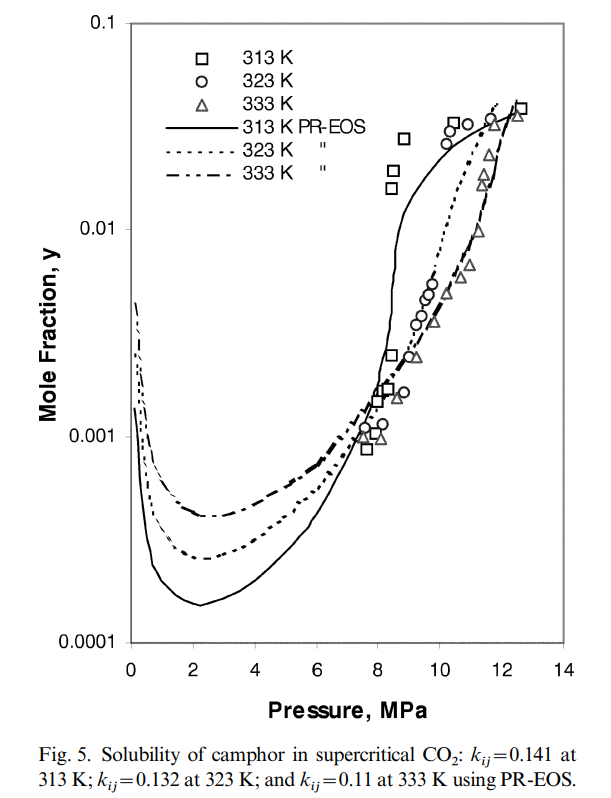

In [112]:
#OBJ: Calcular cuanto CO2 es necesario en gramos. 
#Escogimos una P = 8.5 MPa y una T inicial de 313 K.
#Entonces, tenemos un volumen fijo tambien, la idea es determinar la fraccion de sCO2 necesaria. Y conocemos la de alcanfor que es de 

V = 20e-6 #m^3

#Proceso: Obtener volumen especifico de la mezcla, luego dividir volumen total sobre volumen en 
# especifico, y asi obtenemos el numero de moles totales. Luego eso lo multiplicamos por las fracciones, 
# y luego a cada fraccion por su masa molar, y asi obtenemos las masas requeridas de cada sustancia para estar en 
# una fase homogenea en eas condiciones. Y en base a la grafica, sabemos que al aumentar la temepratura, se formaran dos fases. 
#Usaremos losparametros de interaccion binaria del articulo del cual la grafica es permaneciente a 

kij_313K = 0.132
lij_313K = 0

z1 = 1.92e-2 #Estimado con gemini, aqui entre nos
z2 = 1- z1

z = [z1, z2]


a1, b1, a2, b2 = calc_eos_cst_pure(T)
a12 = np.sqrt(a1 * a2) * (1.0 - k12)
a_matriz = [[a1, a12],[a12,a2]]
bs = [b1, b2]

amixV, bmixV = calc_eos_cst_mix(z[0], z[1], k12, l12, a_matriz, bs)

# def PR_mix(T, P, amix, bmix, phase : Literal['liquid', 'vapor'] = 'liquid'):

v = PR_mix(313, 8.5, amixV, bmixV, phase = 'vapor')

moles = V/v

mW = [chemicals.search_chemical('camphor').MW, chemicals.search_chemical('carbon dioxide').MW]

m= [moles*z[0]*mW[0], moles*z[1]*mW[1]]

print(f"Mass of camphor: {m[0]} g \nMass of CO2: {m[1]} g")


Mass of camphor: 1.840460655929611 g 
Mass of CO2: 27.179542338816013 g


In [62]:
k12, l12 = 5.4695e-2 , -0.6598e-2 #del articulo :)

print(f"Pc\nCamphor:{Pc[0]}\nCO2:{Pc[1]}\n\nTc\nCamphor:{Tc[0]}\nCO2:{Tc[1]}\n\nOmega\nCamphor:{omega[0]}\nCO2:{omega[1]}\n\nBinary Coefficient Parameters\nk12:{k12}\nl12:{l12}\n")

yi = [1.186729e-7, 9.99999880e-1]
xi = [0.00270834, 0.997291166]

# no tienen sentido estas fracciones molares -_-. 
# En ambas predomina el CO2. Pero calcule estas composiciones con Rachfor Rice

T = 313.5540404040404
P = 8.96551724137931

def calc_fugacity_coeff(P, T, mole_fractions, a_matrix, b_vector, a_mix, b_mix, phase_type='vapor'):
    """
    Calcula los coeficientes de fugacidad respetando estrictamente el contrato solicitado.
    Corrige los errores numéricos adaptando las derivadas parciales de las reglas de mezclado.
    """
    y = np.array(mole_fractions)
    b_vector = np.array(b_vector)
    a_matrix = np.array(a_matrix)
    
    # Parámetros adimensionales de la mezcla para la EoS
    A = a_mix * P / (R**2 * T**2)
    B = b_mix * P / (R * T)

    # Coeficientes del polinomio cúbico de Peng-Robinson
    coeff = [
        1.0,
        -(1.0 - B),
        A - 3.0 * B**2 - 2.0 * B,
        -(A * B - B**2 - B**3)
    ]

    # Resolución de raíces reales
    roots = np.roots(coeff)
    roots_real = roots[np.isclose(roots.imag, 0.0, atol=1e-9)].real
    roots_real = np.sort(roots_real)
    
    # Filtro de raíces físicas válidas
    roots_val = [r for r in roots_real if r > B]

    if len(roots_val) == 0:
        raise ValueError(f"No se encontraron raíces reales físicas para Z a T={T} K y P={P/1e6} MPa.")

    # Selección de Z según el estado físico (Fase)
    if phase_type.lower() == 'liquid':
        Z = np.min(roots_val)   
    else:
        Z = np.max(roots_val)

    # Términos del logaritmo de atracción de PR
    sqrt2 = np.sqrt(2.0)
    arg_log = (Z + (1.0 + sqrt2) * B) / (Z + (1.0 - sqrt2) * B)

    if arg_log <= 0:
        raise ValueError("Error de estabilidad: Argumento logarítmico para el término de atracción es inválido.")

    # --- CORRECCIÓN CRÍTICA DE DERIVADAS PARCIALES ---
    # 1. Término de atracción cruzado (A)
    suma_aj = np.dot(a_matrix, y)

    # 2. Reconstrucción analítica de l12 a partir de tu vector y b_mix para obtener la derivada exacta de b
    # bmix = b1*y1^2 + 2*y1*y2*(((b1+b2)/2)*(1-l12)) + b2*y2^2
    # Si y es un componente puro, evitamos divisiones por cero.
    if y[0] > 1e-9 and y[1] > 1e-9:
        termino_cruzado_b = (b_mix - b_vector[0]*y[0]**2 - b_vector[1]*y[1]**2) / (2.0 * y[0] * y[1])
    else:
        termino_cruzado_b = (b_vector[0] + b_vector[1]) / 2.0

    # Gradiente analítico real db/dni para corregir los valores ridículos
    db_di = np.zeros(2)
    db_di[0] = 2.0 * y[0] * b_vector[0] + 2.0 * y[1] * termino_cruzado_b
    db_di[1] = 2.0 * y[1] * b_vector[1] + 2.0 * y[0] * termino_cruzado_b
    # -------------------------------------------------

    # Cálculo final del coeficiente de fugacidad (phi) para cada componente
    phi = np.zeros(2)
    for i in range(2):
        term1 = (db_di[i] / b_mix) * (Z - 1.0)
        term2 = -np.log(Z - B)
        term3 = -A / (2.0 * sqrt2 * B)
        term4 = (2.0 * suma_aj[i] / a_mix) - (db_di[i] / b_mix) # db_di[i]/bmix reemplaza a b_vector[i]/bmix
        term5 = np.log(arg_log)

        ln_phi = term1 + term2 + term3 * term4 * term5
        phi[i] = np.exp(ln_phi)

    return phi # Retorna un array o lista con [phi_CO2, phi_Alcanfor]


def fugac(yi, T, xi, P):
    
    # 1. Calcular constantes puras
    b1 = 0.07780 * (R * Tc[0] / Pc[0])
    a1 = 0.45724 * ((R * Tc[0])**2 / Pc[0]) * (1.0 + (0.37464 + 1.54226 * omega[0] - 0.2699 * omega[0]**2) * (1.0 - (T / Tc[0])**0.5))**2
    b2 = 0.07780 * (R * Tc[1] / Pc[1])
    a2 = 0.45724 * ((R * Tc[1])**2 / Pc[1]) * (1.0 + (0.37464 + 1.54226 * omega[1] - 0.2699 * omega[1]**2) * (1.0 - (T / Tc[1])**0.5))**2
    
    # 2. Matrices y vectores requeridos por el contrato
    a12 = np.sqrt(a1 * a2) * (1.0 - k12)
    a_matriz = [[a1, a12], [a12, a2]]
    bs = [b1, b2]
    
    # 3. Mezclas (usando tus funciones calc_eos_cst_mix)
    amixV, bmixV = calc_eos_cst_mix(yi[0], yi[1], k12, l12, a_matriz, bs)
    amixL, bmixL = calc_eos_cst_mix(xi[0], xi[1], k12, l12, a_matriz, bs)
    
    # 4. Llamadas al nuevo contrato corregido
    phiL = calc_fugacity_coeff(P, T, xi, a_matriz, bs, amixL, bmixL, phase_type='liquid')
    phiV = calc_fugacity_coeff(P, T, yi, a_matriz, bs, amixV, bmixV, phase_type='vapor') 

    return phiL, phiV


phi_L, phi_V = fugac(yi, T, xi, P)

print(f"Camphor\nphi_L: {phi_L[0]}\nphi_V: {phi_V[0]}\n\nCO2\nphi_L: {phi_L[1]}\nphi_V: {phi_V[1]}")

Pc
Camphor:2.99
CO2:7.3773

Tc
Camphor:709.0
CO2:304.1282

Omega
Camphor:0.319
CO2:0.22394

Binary Coefficient Parameters
k12:0.054695
l12:-0.006598

Camphor
phi_L: 4.159786392138613e+28
phi_V: 4.105606004057255e+29

CO2
phi_L: 65960636621.76313
phi_V: 116464422652.34555


**Gemini**

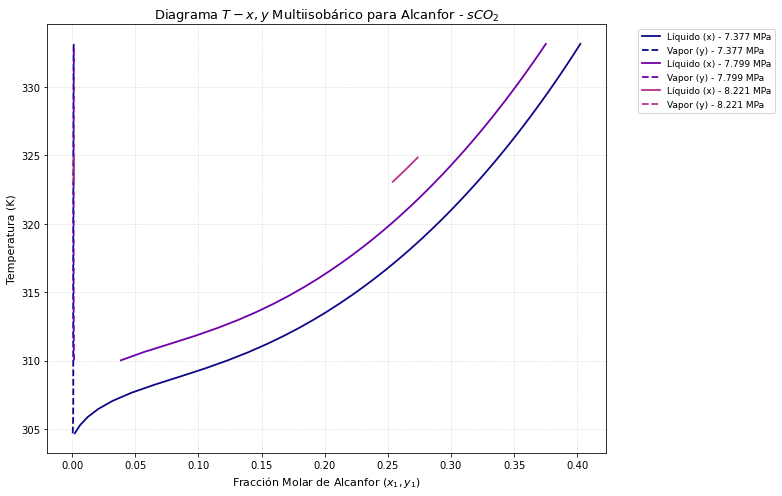

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import chemicals
from scipy.optimize import brentq

class CamphorCO2_VLE:
    def __init__(self, z, k12, l12):
        self.R = 8.314462618e-6  # MPa m3 / mol K
        self.z = np.array(z)     # Composición global [z_camfor, z_CO2]
        self.k12 = k12
        self.l12 = l12
        
        # Propiedades puras (Alcanfor = 0, CO2 = 1)
        cas_camphor = chemicals.search_chemical('camphor').CASs
        cas_co2 = chemicals.search_chemical('carbon dioxide').CASs
        
        self.Tc = np.array([chemicals.Tc(cas_camphor), chemicals.Tc(cas_co2)]) # K
        self.Pc = np.array([chemicals.Pc(cas_camphor)/1e6, chemicals.Pc(cas_co2)/1e6]) # MPa
        self.omega = np.array([chemicals.omega(cas_camphor), chemicals.omega(cas_co2)])

    def wilson_K(self, T, P):
        lnKi = np.log(self.Pc / P) + 5.373 * (1 + self.omega) * (1 - self.Tc / T)
        return np.exp(lnKi)

    def calc_eos_cst_pure(self, T):
        b = 0.07780 * (self.R * self.Tc / self.Pc)
        kappa = 0.37464 + 1.54226 * self.omega - 0.2699 * self.omega**2
        alpha = (1 + kappa * (1 - np.sqrt(T / self.Tc)))**2
        a = 0.45724 * ((self.R * self.Tc)**2 / self.Pc) * alpha
        return a, b

    def calc_eos_cst_mix(self, y, a, b):
        a_matrix = np.array([
            [a[0], np.sqrt(a[0]*a[1])*(1-self.k12)],
            [np.sqrt(a[0]*a[1])*(1-self.k12), a[1]]
        ])
        bmix = b[0]*y[0]**2 + 2*y[0]*y[1]*(((b[0]+b[1])/2)*(1-self.l12)) + b[1]*y[1]**2
        amix = a_matrix[0,0]*y[0]**2 + a_matrix[1,1]*y[1]**2 + 2*a_matrix[0,1]*y[0]*y[1]
        return amix, bmix, a_matrix

    def calc_fugacity_coeff(self, T, P, fractions, a, b, phase_type='vapor'):
        amix, bmix, a_matrix = self.calc_eos_cst_mix(fractions, a, b)
        A = amix * P / (self.R**2 * T**2)
        B = bmix * P / (self.R * T)

        coeff = [1.0, -(1.0 - B), A - 3.0 * B**2 - 2.0 * B, -(A * B - B**2 - B**3)]
        roots = np.roots(coeff)
        roots_real = roots[np.isclose(roots.imag, 0.0, atol=1e-9)].real
        
        valid_roots = [r for r in roots_real if r > B]
        if not valid_roots:
            return None
            
        Z = min(valid_roots) if phase_type == 'liquid' else max(valid_roots)
        sqrt2 = np.sqrt(2.0)
        arg_log = (Z + (1.0 + sqrt2) * B) / (Z + (1.0 - sqrt2) * B)
        suma_aj = np.dot(a_matrix, fractions)
        
        term1 = (b / bmix) * (Z - 1.0)
        term2 = -np.log(Z - B)
        term3 = -A / (2.0 * sqrt2 * B)
        term4 = (2.0 * suma_aj / amix) - (b / bmix)
        term5 = np.log(arg_log)

        ln_phi = term1 + term2 + term3 * term4 * term5
        return np.exp(ln_phi)

    def errorRR(self, beta, K):
        return self.z[0] * (K[0] - 1) / (1 + beta * (K[0] - 1)) + self.z[1] * (K[1] - 1) / (1 + beta * (K[1] - 1))

    def solve_flash(self, T, P, max_iter=80, tol=1e-5): #flash ideal
        K = self.wilson_K(T, P)
        a, b = self.calc_eos_cst_pure(T)
        
        for _ in range(max_iter):
            try:
                beta = brentq(self.errorRR, 0.0, 1.0, args=(K,))
            except ValueError:
                return None, None 

            x = self.z / (1 + beta * (K - 1))
            y = K * x
            x /= sum(x)
            y /= sum(y)

            phiL = self.calc_fugacity_coeff(T, P, x, a, b, 'liquid')
            phiV = self.calc_fugacity_coeff(T, P, y, a, b, 'vapor')
            
            if phiL is None or phiV is None:
                return None, None
                
            K_new = phiL / phiV
            if np.sum(np.abs(K_new - K)) < tol:
                return x, y
            K = K_new

        return None, None

# --- Parámetros del Sistema ---
z_feed = [0.0015, 1 - 0.0015] # [Alcanfor, CO2]
k12, l12 = 5.4695e-2, -0.6598e-2
temperatures = np.linspace(298.15, 333.15, 60)

# Inicializar modelo unificado
vle_model = CamphorCO2_VLE(z_feed, k12, l12)

# Definir el rango de isobaras solicitado
P_c_CO2 = vle_model.Pc[1]  # Presión crítica extraída dinámicamente (~7.377 MPa)
P_max = (1300 * 0.00689476) + 0.101325  # 1300 psig en MPa absolute (~9.065 MPa)
isobaras = np.linspace(P_c_CO2, P_max, 5) # Generar 5 curvas distribuidas

# --- Gráfico de Resultados ---
plt.figure(figsize=(11, 7))

# Paleta de colores estándar para distinguir las presiones
colors = plt.cm.plasma(np.linspace(0, 0.85, len(isobaras)))

for P, color in zip(isobaras, colors):
    x_list, y_list, T_list = [], [], []
    
    for T in temperatures:
        x, y = vle_model.solve_flash(T, P)
        if x is not None and y is not None:
            T_list.append(T)
            x_list.append(x[0]) # Fracción molar de Alcanfor en líquido
            y_list.append(y[0]) # Fracción molar de Alcanfor en vapor
            
    if T_list:
        # Graficar Líquido (línea continua) y Vapor (línea discontinua) compartiendo color por presión
        plt.plot(x_list, T_list, linestyle='-', color=color, linewidth=1.8,
                 label=f'Líquido (x) - {P:.3f} MPa')
        plt.plot(y_list, T_list, linestyle='--', color=color, linewidth=1.8,
                 label=f'Vapor (y) - {P:.3f} MPa')

plt.title('Diagrama $T-x,y$ Multiisobárico para Alcanfor - $sCO_2$', fontsize=13)
plt.xlabel('Fracción Molar de Alcanfor ($x_1, y_1$)', fontsize=11)
plt.ylabel('Temperatura (K)', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)

# Organizar la leyenda para evitar duplicados masivos y mantener claridad
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

Calculating supercritical solubility limits...


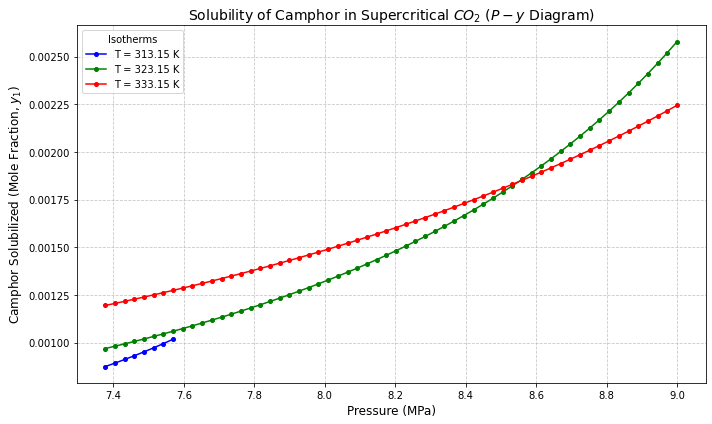

In [68]:
import numpy as np
import matplotlib.pyplot as plt
import chemicals
from scipy.optimize import brentq

class CamphorCO2_VLE:
    def __init__(self, z, k12, l12):
        self.R = 8.314462618e-6  # MPa m3 / mol K
        self.z = np.array(z)     # Global composition [z_camphor, z_CO2]
        self.k12 = k12
        self.l12 = l12
        
        # Pure component properties
        cas_camphor = chemicals.search_chemical('camphor').CASs
        cas_co2 = chemicals.search_chemical('carbon dioxide').CASs
        
        self.Tc = np.array([chemicals.Tc(cas_camphor), chemicals.Tc(cas_co2)])
        self.Pc = np.array([chemicals.Pc(cas_camphor)/1e6, chemicals.Pc(cas_co2)/1e6])
        self.omega = np.array([chemicals.omega(cas_camphor), chemicals.omega(cas_co2)])

    def wilson_K(self, T, P):
        lnKi = np.log(self.Pc / P) + 5.373 * (1 + self.omega) * (1 - self.Tc / T)
        return np.exp(lnKi)

    def calc_eos_cst_pure(self, T):
        b = 0.07780 * (self.R * self.Tc / self.Pc)
        kappa = 0.37464 + 1.54226 * self.omega - 0.2699 * self.omega**2
        alpha = (1 + kappa * (1 - np.sqrt(T / self.Tc)))**2
        a = 0.45724 * ((self.R * self.Tc)**2 / self.Pc) * alpha
        return a, b

    def calc_eos_cst_mix(self, y, a, b):
        a_matrix = np.array([
            [a[0], np.sqrt(a[0]*a[1])*(1-self.k12)],
            [np.sqrt(a[0]*a[1])*(1-self.k12), a[1]]
        ])
        bmix = b[0]*y[0]**2 + 2*y[0]*y[1]*(((b[0]+b[1])/2)*(1-self.l12)) + b[1]*y[1]**2
        amix = a_matrix[0,0]*y[0]**2 + a_matrix[1,1]*y[1]**2 + 2*a_matrix[0,1]*y[0]*y[1]
        return amix, bmix, a_matrix

    def calc_fugacity_coeff(self, T, P, fractions, a, b, phase_type='vapor'):
        amix, bmix, a_matrix = self.calc_eos_cst_mix(fractions, a, b)
        A = amix * P / (self.R**2 * T**2)
        B = bmix * P / (self.R * T)

        coeff = [1.0, -(1.0 - B), A - 3.0 * B**2 - 2.0 * B, -(A * B - B**2 - B**3)]
        roots = np.roots(coeff)
        roots_real = roots[np.isclose(roots.imag, 0.0, atol=1e-9)].real
        
        valid_roots = [r for r in roots_real if r > B]
        if not valid_roots:
            return None
            
        Z = min(valid_roots) if phase_type == 'liquid' else max(valid_roots)
        sqrt2 = np.sqrt(2.0)
        arg_log = (Z + (1.0 + sqrt2) * B) / (Z + (1.0 - sqrt2) * B)
        suma_aj = np.dot(a_matrix, fractions)
        
        term1 = (b / bmix) * (Z - 1.0)
        term2 = -np.log(Z - B)
        term3 = -A / (2.0 * sqrt2 * B)
        term4 = (2.0 * suma_aj / amix) - (b / bmix)
        term5 = np.log(arg_log)

        ln_phi = term1 + term2 + term3 * term4 * term5
        return np.exp(ln_phi)

    def errorRR(self, beta, K):
        return self.z[0] * (K[0] - 1) / (1 + beta * (K[0] - 1)) + self.z[1] * (K[1] - 1) / (1 + beta * (K[1] - 1))

    def solve_flash(self, T, P, max_iter=100, tol=1e-5):
        K = self.wilson_K(T, P)
        a, b = self.calc_eos_cst_pure(T)
        
        for _ in range(max_iter):
            try:
                beta = brentq(self.errorRR, 0.0, 1.0, args=(K,))
            except ValueError:
                return None, None 

            x = self.z / (1 + beta * (K - 1))
            y = K * x
            x /= sum(x)
            y /= sum(y)

            phiL = self.calc_fugacity_coeff(T, P, x, a, b, 'liquid')
            phiV = self.calc_fugacity_coeff(T, P, y, a, b, 'vapor')
            
            if phiL is None or phiV is None:
                return None, None
                
            K_new = phiL / phiV
            if np.sum(np.abs(K_new - K)) < tol:
                return x, y
            K = K_new

        return None, None

# --- System Parameters ---
# Increased global camphor composition to ensure we hit the two-phase boundary 
# across a broader pressure range.
z_feed = [0.15, 0.85] 
k12, l12 = 5.4695e-2, -0.6598e-2

vle_model = CamphorCO2_VLE(z_feed, k12, l12)

# --- Define Isotherms and Pressure Range ---
isotherms = [313.15, 323.15, 333.15] # K
pressures = np.linspace(P_c_CO2, 9, 60) # MPa (from just above Pc up to 25 MPa)

# --- Generate Plot Data ---
plt.figure(figsize=(10, 6))
colors = ['blue', 'green', 'red']

print("Calculating supercritical solubility limits...")

for T, color in zip(isotherms, colors):
    y_camphor_list = []
    P_plot = []
    
    for P in pressures:
        x, y = vle_model.solve_flash(T, P)
        # We only care about the vapor/supercritical phase composition (y)
        if x is not None and y is not None:
            P_plot.append(P)
            y_camphor_list.append(y[0]) 
            
    if P_plot:
        plt.plot(P_plot, y_camphor_list, linestyle='-', marker='o', markersize=4, 
                 color=color, label=f'T = {T} K')

# --- Plot Formatting ---
plt.title('Solubility of Camphor in Supercritical $CO_2$ ($P-y$ Diagram)', fontsize=14)
plt.xlabel('Pressure (MPa)', fontsize=12)
plt.ylabel('Camphor Solubilized (Mole Fraction, $y_1$)', fontsize=12)
plt.legend(title="Isotherms", loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)

# Note: Supercritical solubility is often plotted on a log scale for the Y-axis
# If you prefer that, uncomment the line below:
# plt.yscale('log')

plt.tight_layout()
plt.show()

Calculating P-x,y envelope for T = 313.15 K...


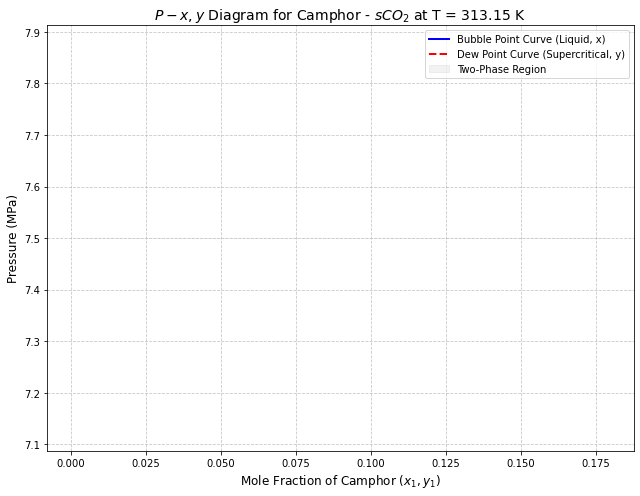

In [70]:
import numpy as np
import matplotlib.pyplot as plt
import chemicals
from scipy.optimize import brentq

class CamphorCO2_VLE:
    def __init__(self, z, k12, l12):
        self.R = 8.314462618e-6  # MPa m3 / mol K
        self.z = np.array(z)     # Global composition [z_camphor, z_CO2]
        self.k12 = k12
        self.l12 = l12
        
        # Pure component properties
        cas_camphor = chemicals.search_chemical('camphor').CASs
        cas_co2 = chemicals.search_chemical('carbon dioxide').CASs
        
        self.Tc = np.array([chemicals.Tc(cas_camphor), chemicals.Tc(cas_co2)])
        self.Pc = np.array([chemicals.Pc(cas_camphor)/1e6, chemicals.Pc(cas_co2)/1e6])
        self.omega = np.array([chemicals.omega(cas_camphor), chemicals.omega(cas_co2)])

    def wilson_K(self, T, P):
        lnKi = np.log(self.Pc / P) + 5.373 * (1 + self.omega) * (1 - self.Tc / T)
        return np.exp(lnKi)

    def calc_eos_cst_pure(self, T):
        b = 0.07780 * (self.R * self.Tc / self.Pc)
        kappa = 0.37464 + 1.54226 * self.omega - 0.2699 * self.omega**2
        alpha = (1 + kappa * (1 - np.sqrt(T / self.Tc)))**2
        a = 0.45724 * ((self.R * self.Tc)**2 / self.Pc) * alpha
        return a, b

    def calc_eos_cst_mix(self, y, a, b):
        a_matrix = np.array([
            [a[0], np.sqrt(a[0]*a[1])*(1-self.k12)],
            [np.sqrt(a[0]*a[1])*(1-self.k12), a[1]]
        ])
        bmix = b[0]*y[0]**2 + 2*y[0]*y[1]*(((b[0]+b[1])/2)*(1-self.l12)) + b[1]*y[1]**2
        amix = a_matrix[0,0]*y[0]**2 + a_matrix[1,1]*y[1]**2 + 2*a_matrix[0,1]*y[0]*y[1]
        return amix, bmix, a_matrix

    def calc_fugacity_coeff(self, T, P, fractions, a, b, phase_type='vapor'):
        amix, bmix, a_matrix = self.calc_eos_cst_mix(fractions, a, b)
        A = amix * P / (self.R**2 * T**2)
        B = bmix * P / (self.R * T)

        coeff = [1.0, -(1.0 - B), A - 3.0 * B**2 - 2.0 * B, -(A * B - B**2 - B**3)]
        roots = np.roots(coeff)
        roots_real = roots[np.isclose(roots.imag, 0.0, atol=1e-9)].real
        
        valid_roots = [r for r in roots_real if r > B]
        if not valid_roots:
            return None
            
        Z = min(valid_roots) if phase_type == 'liquid' else max(valid_roots)
        sqrt2 = np.sqrt(2.0)
        arg_log = (Z + (1.0 + sqrt2) * B) / (Z + (1.0 - sqrt2) * B)
        suma_aj = np.dot(a_matrix, fractions)
        
        term1 = (b / bmix) * (Z - 1.0)
        term2 = -np.log(Z - B)
        term3 = -A / (2.0 * sqrt2 * B)
        term4 = (2.0 * suma_aj / amix) - (b / bmix)
        term5 = np.log(arg_log)

        ln_phi = term1 + term2 + term3 * term4 * term5
        return np.exp(ln_phi)

    def errorRR(self, beta, K):
        return self.z[0] * (K[0] - 1) / (1 + beta * (K[0] - 1)) + self.z[1] * (K[1] - 1) / (1 + beta * (K[1] - 1))

    def solve_flash(self, T, P, max_iter=100, tol=1e-5):
        K = self.wilson_K(T, P)
        a, b = self.calc_eos_cst_pure(T)
        
        for _ in range(max_iter):
            try:
                beta = brentq(self.errorRR, 0.0, 1.0, args=(K,))
            except ValueError:
                return None, None 

            x = self.z / (1 + beta * (K - 1))
            y = K * x
            x /= sum(x)
            y /= sum(y)

            phiL = self.calc_fugacity_coeff(T, P, x, a, b, 'liquid')
            phiV = self.calc_fugacity_coeff(T, P, y, a, b, 'vapor')
            
            if phiL is None or phiV is None:
                return None, None
                
            K_new = phiL / phiV
            if np.sum(np.abs(K_new - K)) < tol:
                return x, y
            K = K_new

        return None, None

# --- System Parameters ---
z_feed = [0.15, 0.85] # Global composition [Camphor, sCO2]
k12, l12 = 5.4695e-2, -0.6598e-2

vle_model = CamphorCO2_VLE(z_feed, k12, l12)

# --- Define Isotherm and Pressure Range ---
T_isotherm = 313.15 # K (40 °C)
# Sweeping from just above CO2 Pc (7.38 MPa) up to 25 MPa
pressures = np.linspace(7.5, 25.0, 80) 

# --- Generate Plot Data ---
print(f"Calculating P-x,y envelope for T = {T_isotherm} K...")
x_camphor_list = []
y_camphor_list = []
P_plot = []

for P in pressures:
    x, y = vle_model.solve_flash(T_isotherm, P)
    if x is not None and y is not None:
        P_plot.append(P)
        x_camphor_list.append(x[0]) # Liquid phase camphor fraction
        y_camphor_list.append(y[0]) # Vapor/Supercritical phase camphor fraction

# --- Plot Formatting ---
plt.figure(figsize=(9, 7))

if P_plot:
    plt.plot(x_camphor_list, P_plot, 'b-', linewidth=2, label='Bubble Point Curve (Liquid, x)')
    plt.plot(y_camphor_list, P_plot, 'r--', linewidth=2, label='Dew Point Curve (Supercritical, y)')
    
    # Fill the two-phase region for better visual clarity
    plt.fill_betweenx(P_plot, x_camphor_list, y_camphor_list, color='gray', alpha=0.1, label='Two-Phase Region')

plt.title(f'$P-x,y$ Diagram for Camphor - $sCO_2$ at T = {T_isotherm} K', fontsize=14)
plt.xlabel('Mole Fraction of Camphor ($x_1, y_1$)', fontsize=12)
plt.ylabel('Pressure (MPa)', fontsize=12)
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.7)

# Depending on your specific system, camphor solubility in the supercritical phase 
# might be very small compared to the liquid phase. Uncomment below if the dew point curve looks "squished" against the axis.
# plt.xscale('log') 

plt.tight_layout()
plt.show()